Computing a global dendrogram by merging local, vertically split dendrograms
============================================================================

Since the dendrogram is a very global operation and it can be difficult to merge horizontally split dendrograms, we try vertical splitting as suggested by @LarsvE568.

Let's start by doing some imports and defining the data

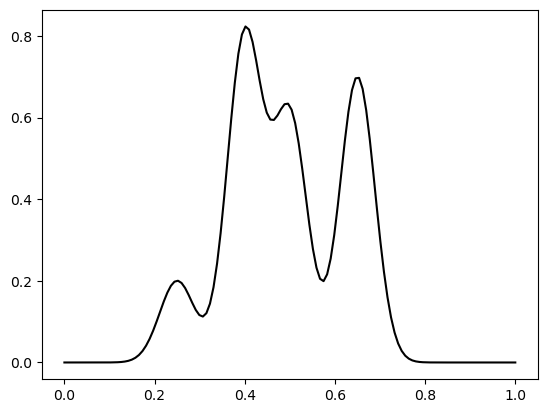

In [1]:
import heat as ht
import numpy as np
import matplotlib.pyplot as plt
from dendro.utils import get_1d_data
from astrodendro.dendrogram import Dendrogram

x, data = get_1d_data(128)
plt.plot(x.larray, data.larray, color="black")

Next, we define the vertical split.
To this end, we need to sort the data and then get local data by applying a slice on the sorted indices.
We include a halo, so that we can later tell more easily how to merge structures from adjacent dendrograms

In [2]:
ntasks = 4
elements_per_task = int(np.ceil(data.shape[0] / ntasks))
halo_size = 4

In [3]:
local_slices = [
    slice(i * elements_per_task, (i + 1) * elements_per_task) for i in range(ntasks)
]
for i in range(ntasks):
    start = i * elements_per_task
    stop = start + elements_per_task
    if i > 0:
        start -= halo_size
    if i < ntasks - 1:
        stop += halo_size
    local_slices[i] = slice(start, stop)

In [4]:
idx = np.argsort(data.numpy())
local_idx = [
    sorted(idx[s]) for s in local_slices
]  # we need to sort the indices to express adjacency for the subsequent dendrogram computation

Let's see the data on each task

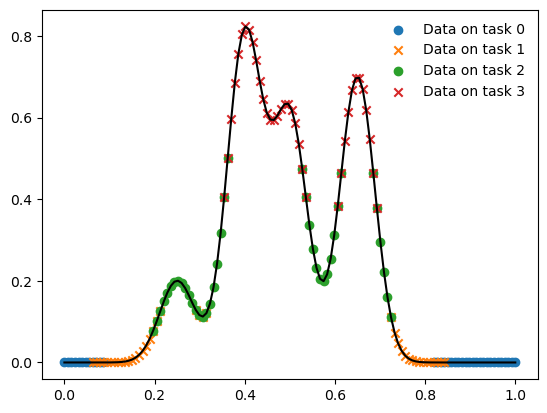

In [5]:
plt.plot(x.larray, data.larray, color="black")
for i in range(ntasks):
    marker = "o" if i % 2 == 0 else "x"
    plt.scatter(
        x[local_idx[i]], data[local_idx[i]], marker=marker, label=f"Data on task {i}"
    )
plt.legend(frameon=False)

Next, we simply compute dendrograms on the local data.

In [6]:
local_dendrograms = [
    Dendrogram.compute(np.array(data.larray)[_idx]) for _idx in local_idx
]

/var/folders/zl/pxyz2x2x591c234cc02rcn_40000gn/T/ipykernel_81449/3187722715.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  Dendrogram.compute(np.array(data.larray)[_idx]) for _idx in local_idx


Before we continue, we have to map the local indices in the local dendrograms to global indices

In [7]:
def local_to_global_index(_local_idx, leaves):
    for leaf in leaves:
        leaf._indices = [_local_idx[i[0]] for i in leaf._indices]
        local_to_global_index(_local_idx=_local_idx, leaves=leaf._children)


for i in range(ntasks):
    local_to_global_index(local_idx[i], local_dendrograms[i].trunk)

Let's plot the local dendrograms

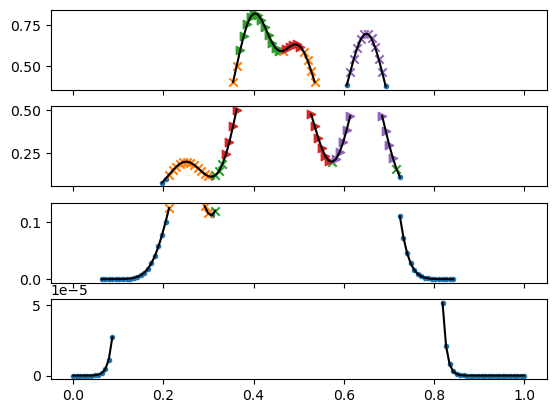

In [8]:
def plot_astrodendro_leaves(ax, leaves, level=0):
    markers = {0: ".", 1: "x", 2: ">", 3: "o", 4: "<"}
    for leaf in leaves:
        ax.scatter(
            x.numpy()[leaf._indices],
            data.numpy()[leaf._indices],
            marker=markers[level],
        )
        plot_astrodendro_leaves(ax=ax, leaves=leaf._children, level=level + 1)


fig, axs = plt.subplots(ntasks, 1, sharex=True)
for i in range(ntasks):
    ax = axs[-i - 1] if ntasks > 1 else axs
    _data = data.copy()
    _data[...] = np.nan
    _data[local_idx[i]] = data[local_idx[i]]
    ax.plot(x.larray, _data.larray, color="black")

    plot_astrodendro_leaves(ax, local_dendrograms[i].trunk)

Ok great! Let's have a look at the global dendrogram that we want to recover

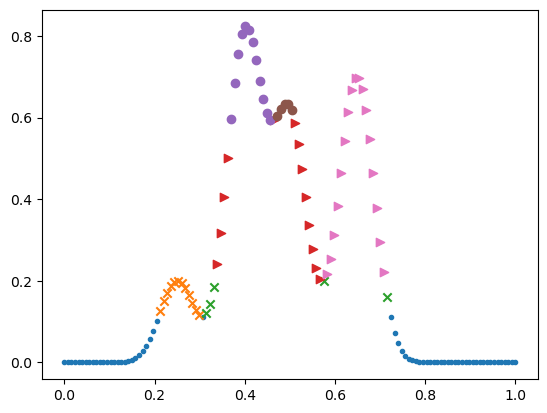

In [9]:
global_dendrogram = Dendrogram.compute(data.numpy())

fig, ax = plt.subplots()
plot_astrodendro_leaves(ax, global_dendrogram.trunk)

Alright, now let's figure out how to merge these local dendrograms with the correct tree structure!

We are going to merge them successively from the top down.
Because of the halo, we have overlap between some leaves of the bottom dendrogram and the trunk and some branches of the top dendrogram.
Whenever a structure shares indices, it should be merged.
We need to take some care because the trunk and some of its children may need to be merged to the same structure, but otherwise, we can simply merge and then glue the children of the top part of the structure onto the merged structure.

In [10]:
merged_dendrogram = local_dendrograms[-1]


def merge_dendrograms(attach_to, to_merge):

    # get the top level leaves of the dendrogram to be merged
    def _get_top_leaves(leaf, all_leaves):
        if len(leaf.children) == 0:
            all_leaves.append(leaf)
        else:
            for child in leaf.children:
                _get_top_leaves(child, all_leaves)

    top_level_leaves = []
    _get_top_leaves(to_merge.trunk[0], top_level_leaves)

    # loop through the top leaves and merge them to the bottom of the merged dendrogram
    for leaf in top_level_leaves:
        leaf_has_been_merged = False

        # go through the children of the trunks and see if they should be merged to any leaves
        for child in attach_to.trunk[0].children:
            intersection = np.intersect1d(child._indices, leaf._indices)
            if len(intersection) > 0:  # structure should be attached here
                leaf._indices = list(
                    np.unique(np.append(child._indices, leaf._indices))
                )
                leaf.children = child.children
                leaf_has_been_merged = True
        if leaf_has_been_merged:
            continue

        # otherwise, we merge with the trunk
        for child in attach_to.trunk:
            intersection = np.intersect1d(child._indices, leaf._indices)
            if len(intersection) > 0:  # structure should be attached here
                leaf._indices = list(
                    np.unique(np.append(child._indices, leaf._indices))
                )
                leaf.children = child.children
                leaf_has_been_merged = True
        if leaf_has_been_merged:
            continue

    return to_merge

Let's plot the successive merging

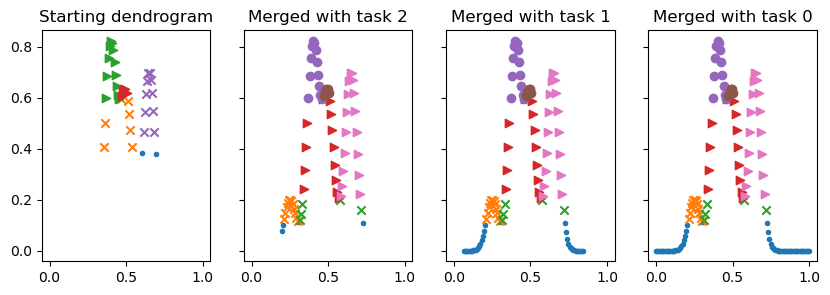

In [11]:
fig, axs = plt.subplots(1, ntasks, sharey=True, sharex=True, figsize=(ntasks * 2.5, 3))
plot_astrodendro_leaves(axs[0], merged_dendrogram.trunk)
axs[0].set_title("Starting dendrogram")

for i in range(1, ntasks):
    merged_dendrogram = merge_dendrograms(merged_dendrogram, local_dendrograms[-i - 1])
    plot_astrodendro_leaves(axs[i], merged_dendrogram.trunk)
    axs[i].set_title(f"Merged with task {ntasks - i -1}")

Now let's make sure that the merged dendrogram matches the global one exactly

In [12]:
def compare_dendrograms(structure_1, structure_2, level=0):
    assert len(structure_1) == len(
        structure_2
    ), f"Different number of features on {level=}"
    for i in range(len(structure_1)):
        _idx_1 = sorted(np.array(structure_1[i]._indices).flatten())
        _idx_2 = sorted(np.array(structure_2[i]._indices).flatten())
        assert len(structure_1[i]._indices) == len(
            structure_2[i]._indices
        ), f"Features {i} on {level=} have different number of indices ({_idx_1} and {_idx_2}"
        assert np.allclose(
            _idx_1, _idx_2
        ), f"Features {i} on {level=} have different indices {_idx_1} and {_idx_2}"
        assert len(structure_1[i].children) == len(
            structure_2[i].children
        ), f"Features {i} on {level=} have different number of children"

        compare_dendrograms(
            structure_1[i].children, structure_2[i].children, level=level + 1
        )
    if level == 0:
        print(f"No deviations between dendrograms found!")


compare_dendrograms(global_dendrogram.trunk, merged_dendrogram.trunk)

No deviations between dendrograms found!


Awesome!

There are some issues, though. Mainly that, if the halo is insufficient to merge the dendrograms, we run into trouble and on real data, it may be difficult to choose a reasonable halo.

In [13]:
if __name__ == "__main__":
    plt.show()